In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("1-employee_salary_dataset.csv")

In [3]:
df.head()

,Employee_ID,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA
0,EMP10001,28.0,Male,Master,6.0,Operations,Junior,1,4,15,Yes,Chennai,6,5,97.0,35.24
1,EMP10002,26.0,Female,Bachelor,5.0,Operations,Junior,2,3,32,No,Delhi,0,18,62.0,35.87
2,EMP10003,31.0,Female,Bachelor,5.0,Marketing,Junior,4,5,17,Yes,Hyderabad,4,7,98.0,35.40
3,EMP10004,59.0,Female,Bachelor,29.0,Sales,Lead,3,0,46,No,Mumbai,14,18,57.0,73.05
4,EMP10005,23.0,Female,Bachelor,0.0,Sales,Junior,2,4,5,Yes,Hyderabad,0,28,56.0,28.83


In [4]:
df.shape

(5020, 16)

In [5]:
df.columns

Index(['Employee_ID', 'Age', 'Gender', 'Education', 'Experience_Years',
       'Department', 'Job_Level', 'Performance_Rating', 'Certifications',
       'Overtime_Hours', 'Remote_Work', 'City', 'Company_Tenure',
       'Projects_Completed', 'Skill_Score', 'Annual_Salary_LPA'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Employee_ID         5020 non-null   str    
 1   Age                 4960 non-null   float64
 2   Gender              5020 non-null   str    
 3   Education           5020 non-null   str    
 4   Experience_Years    4960 non-null   float64
 5   Department          5020 non-null   str    
 6   Job_Level           5020 non-null   str    
 7   Performance_Rating  5020 non-null   int64  
 8   Certifications      5020 non-null   int64  
 9   Overtime_Hours      5020 non-null   int64  
 10  Remote_Work         5020 non-null   str    
 11  City                5020 non-null   str    
 12  Company_Tenure      5020 non-null   int64  
 13  Projects_Completed  5020 non-null   int64  
 14  Skill_Score         4960 non-null   float64
 15  Annual_Salary_LPA   5020 non-null   float64
dtypes: float64(4), in

In [7]:
df.describe()

,Age,Experience_Years,Performance_Rating,Certifications,Overtime_Hours,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA
count,4960.000000,4960.000000,5020.000000,5020.000000,5020.000000,5020.000000,5020.000000,4960.000000,5020.000000
mean,40.468145,11.152419,3.034661,4.986255,29.907968,5.500996,15.481076,74.922984,46.361203
std,11.576821,7.724104,1.411955,3.159127,17.710887,4.415711,8.691489,14.814703,14.427832
min,14.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,50.000000,15.530000
25%,30.000000,5.000000,2.000000,2.000000,15.000000,2.000000,8.000000,62.000000,35.530000
50%,41.000000,11.000000,3.000000,5.000000,30.000000,5.000000,15.000000,75.000000,45.085000
75%,51.000000,17.000000,4.000000,8.000000,45.000000,9.000000,23.000000,88.000000,55.560000
max,90.000000,33.000000,5.000000,10.000000,60.000000,15.000000,30.000000,100.000000,184.190000


In [8]:
df.describe(include='object')

,Employee_ID,Gender,Education,Department,Job_Level,Remote_Work,City
count,5020,5020,5020,5020,5020,5020,5020
unique,3820,2,4,5,5,2,4
top,EMP10001,Female,Bachelor,Marketing,Junior,Yes,Delhi
freq,2,2577,2261,1061,1843,2532,1284


In [9]:
df.dtypes

Employee_ID               str
Age                   float64
Gender                    str
Education                 str
Experience_Years      float64
Department                str
Job_Level                 str
Performance_Rating      int64
Certifications          int64
Overtime_Hours          int64
Remote_Work               str
City                      str
Company_Tenure          int64
Projects_Completed      int64
Skill_Score           float64
Annual_Salary_LPA     float64
dtype: object

In [10]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": (df.isnull().sum()/len(df))*100
})

missing

,Missing Values,Percentage
Employee_ID,0,0.000000
Age,60,1.195219
Gender,0,0.000000
Education,0,0.000000
Experience_Years,60,1.195219
Department,0,0.000000
Job_Level,0,0.000000
Performance_Rating,0,0.000000
Certifications,0,0.000000
Overtime_Hours,0,0.000000


In [11]:
df[df.duplicated()]

,Employee_ID,Age,Gender,Education,Experience_Years,Department,Job_Level,Performance_Rating,Certifications,Overtime_Hours,Remote_Work,City,Company_Tenure,Projects_Completed,Skill_Score,Annual_Salary_LPA


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.drop_duplicates(inplace=True)

In [14]:
df.drop("Employee_ID", axis=1, inplace=True)

In [15]:
num_cols = df.select_dtypes(include=np.number).columns
cat_cols = df.select_dtypes(include='object').columns

print(num_cols)
print(cat_cols)

Index(['Age', 'Experience_Years', 'Performance_Rating', 'Certifications',
       'Overtime_Hours', 'Company_Tenure', 'Projects_Completed', 'Skill_Score',
       'Annual_Salary_LPA'],
      dtype='str')
Index(['Gender', 'Education', 'Department', 'Job_Level', 'Remote_Work',
       'City'],
      dtype='str')


In [16]:
for col in cat_cols:
    print(col)
    print(df[col].unique())
    print("-"*40)

Gender
<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str
----------------------------------------
Education
<ArrowStringArray>
['Master', 'Bachelor', 'Diploma', 'PhD']
Length: 4, dtype: str
----------------------------------------
Department
<ArrowStringArray>
['Operations', 'Marketing', 'Sales', 'IT', 'HR']
Length: 5, dtype: str
----------------------------------------
Job_Level
<ArrowStringArray>
['Junior', 'Lead', 'Mid', 'Senior', 'Manager']
Length: 5, dtype: str
----------------------------------------
Remote_Work
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
----------------------------------------
City
<ArrowStringArray>
['Chennai', 'Delhi', 'Hyderabad', 'Mumbai']
Length: 4, dtype: str
----------------------------------------


In [17]:
df["Gender"] = df["Gender"].str.strip().str.title()

df["Remote_Work"] = df["Remote_Work"].replace({
    "yes":"Yes",
    "YES":"Yes",
    "no":"No",
    "NO":"No"
})

In [18]:
for col in num_cols:
    print(col)
    print(df[col].min(), df[col].max())

Age
14.0 90.0
Experience_Years
0.0 33.0
Performance_Rating
1 5
Certifications
0 10
Overtime_Hours
0 60
Company_Tenure
0 15
Projects_Completed
1 30
Skill_Score
50.0 100.0
Annual_Salary_LPA
15.53 184.19


In [19]:
df.loc[df["Age"] < 18, "Age"] = np.nan
df.loc[df["Experience_Years"] < 0, "Experience_Years"] = np.nan

In [20]:
for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

In [21]:
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

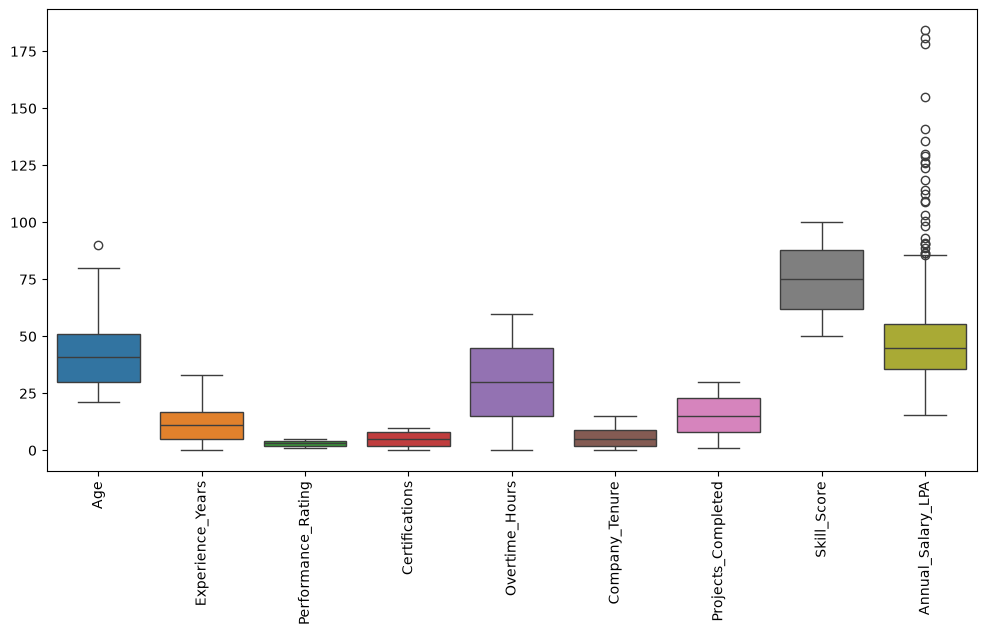

In [22]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df[num_cols])
plt.xticks(rotation=90)
plt.show()

In [23]:
for col in num_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df = df[(df[col]>=lower) & (df[col]<=upper)]

In [24]:
df.shape

(4809, 15)

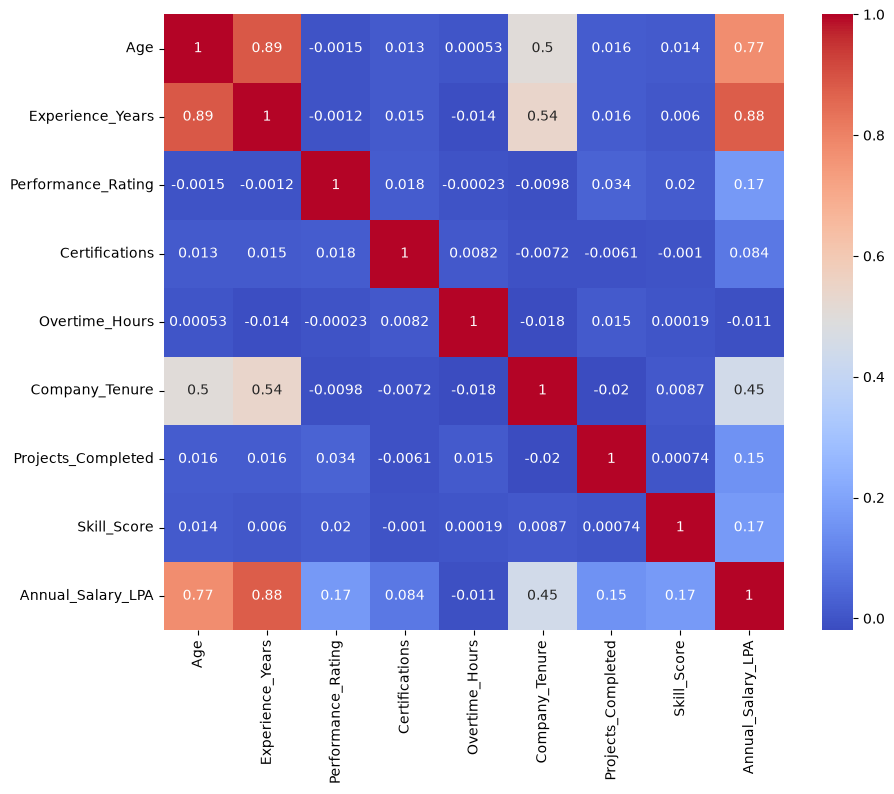

In [25]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

In [26]:
encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col])

In [27]:
X = df.drop("Annual_Salary_LPA", axis=1)

y = df["Annual_Salary_LPA"]

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [29]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [30]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](14,)","[-0.13, 0.07, 2.24,...,-0.3 , 1.74, 2.22]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,46.03
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,14
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(14)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](14,)","[106.57, 64.73, 63.89,..., 47.58, 36.26, 20.72]"


In [31]:
y_pred = model.predict(X_test)

In [32]:
print("MAE :", mean_absolute_error(y_test,y_pred))

print("MSE :", mean_squared_error(y_test,y_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test,y_pred)))

print("R2 Score :", r2_score(y_test,y_pred))

MAE : 3.322727475506208
MSE : 17.033909555366193
RMSE : 4.127215714663603
R2 Score : 0.9031063322895014


In [33]:
result = pd.DataFrame({
    "Actual":y_test,
    "Predicted":y_pred
})

result.head(10)

,Actual,Predicted
1512,39.83,37.485675
3071,47.00,48.184347
830,65.65,63.658946
1075,34.83,34.996179
8,34.69,34.064266
1826,33.42,37.834982
1932,57.96,60.856856
263,23.94,18.005710
3995,31.93,34.910793
4288,66.19,64.471138


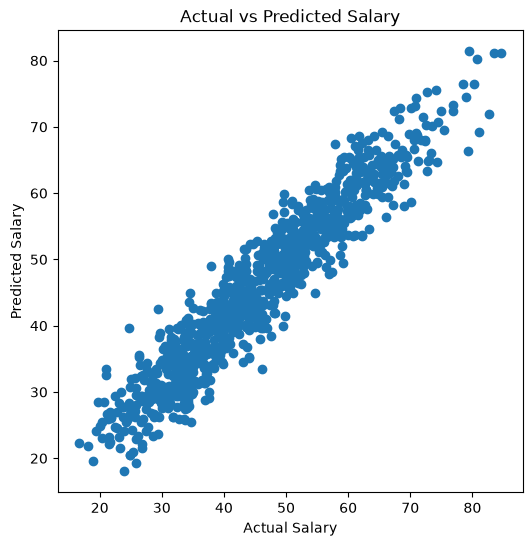

In [34]:
plt.figure(figsize=(6,6))

plt.scatter(y_test,y_pred)

plt.xlabel("Actual Salary")

plt.ylabel("Predicted Salary")

plt.title("Actual vs Predicted Salary")

plt.show()

In [35]:
new_employee = [[30, 5, 88, 4, 1, 0, 2, 1]]

In [36]:
print(X.columns)

Index(['Age', 'Gender', 'Education', 'Experience_Years', 'Department',
       'Job_Level', 'Performance_Rating', 'Certifications', 'Overtime_Hours',
       'Remote_Work', 'City', 'Company_Tenure', 'Projects_Completed',
       'Skill_Score'],
      dtype='str')


In [37]:
print(len(X.columns))

14


In [38]:
new_employee = pd.DataFrame([[0]*len(X.columns)], columns=X.columns)

In [39]:
new_employee["Age"] = 30
new_employee["Experience_Years"] = 5


In [40]:
new_employee = scaler.transform(new_employee)
prediction = model.predict(new_employee)

print(prediction)

[13.46678546]


In [41]:
new_employee = pd.DataFrame({
    "Age":[30],
    "Gender":[1],
    "Education":[2],
    "Experience_Years":[5],
    "Department":[1],
    "Job_Level":[2],
    "Performance_Rating":[4],
    "Certifications":[3],
    "Overtime_Hours":[10],
    "Remote_Work":[1],
    "City":[0],
    "Company_Tenure":[4],
    "Projects_Completed":[8],
    "Skill_Score":[88]
})

In [42]:
new_employee = scaler.transform(new_employee)

prediction = model.predict(new_employee)

print("Predicted Salary (LPA):", prediction[0])

Predicted Salary (LPA): 38.669253878156944


In [43]:
new_employee = scaler.transform(new_employee)
prediction = model.predict(new_employee)

print(prediction)

[6.37183862]


In [44]:
import joblib

joblib.dump(model, "salary_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [45]:
joblib.dump(encoder, "encoder.pkl")

['encoder.pkl']